In [1]:
%pip install polars scikit-learn matplotlib seaborn scipy umap-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Files in dataset: ['dns.txt', 'auth.txt', 'redteam.txt', 'flows.txt', 'proc.txt']

Shape: (40821591, 3)

Schema: Schema({'column_1': Int64, 'column_2': String, 'column_3': String})

First 5 rows:
shape: (5, 3)
┌──────────┬──────────┬──────────┐
│ column_1 ┆ column_2 ┆ column_3 │
│ ---      ┆ ---      ┆ ---      │
│ i64      ┆ str      ┆ str      │
╞══════════╪══════════╪══════════╡
│ 2        ┆ C4653    ┆ C5030    │
│ 2        ┆ C5782    ┆ C16712   │
│ 6        ┆ C1191    ┆ C419     │
│ 15       ┆ C3380    ┆ C22841   │
│ 18       ┆ C2436    ┆ C5030    │
└──────────┴──────────┴──────────┘

Basic Statistics:
shape: (9, 4)
┌────────────┬───────────────┬──────────┬──────────┐
│ statistic  ┆ column_1      ┆ column_2 ┆ column_3 │
│ ---        ┆ ---           ┆ ---      ┆ ---      │
│ str        ┆ f64           ┆ str      ┆ str      │
╞════════════╪═══════════════╪══════════╪══════════╡
│ count      ┆ 4.0821591e7   ┆ 40821591 ┆ 40821591 │
│ null_count ┆ 0.0           ┆ 0        ┆ 0        │
│

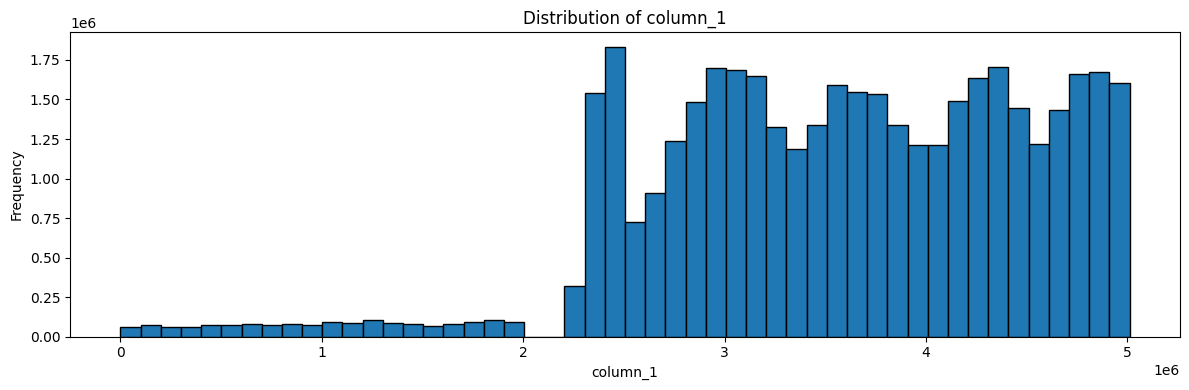

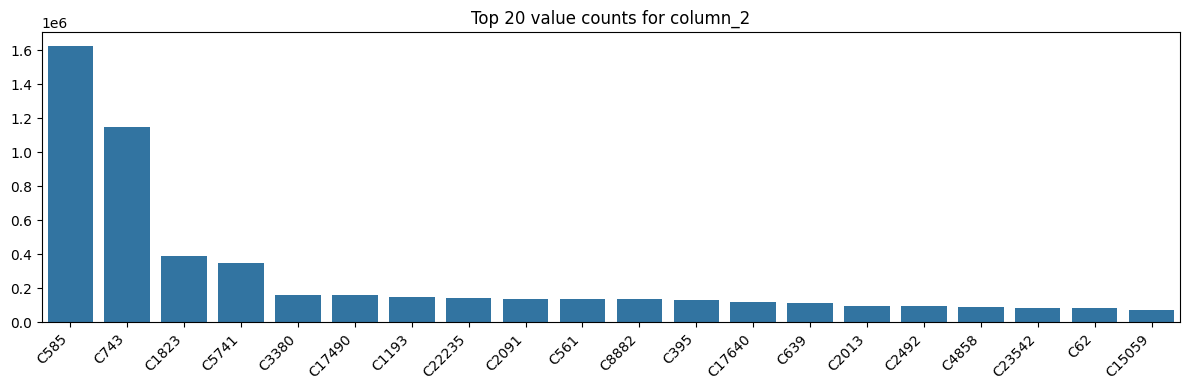

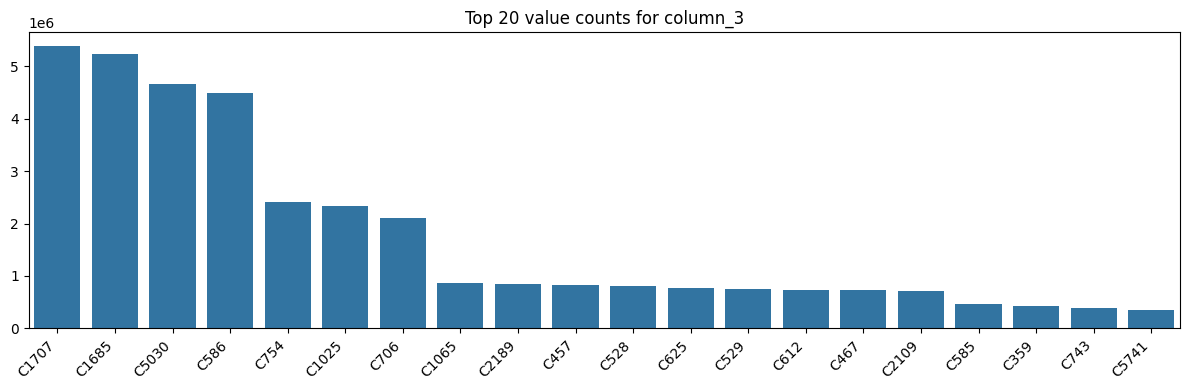

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_36038/4019285987.py:56: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  time_series = df.group_by(time_col).count().sort(time_col)


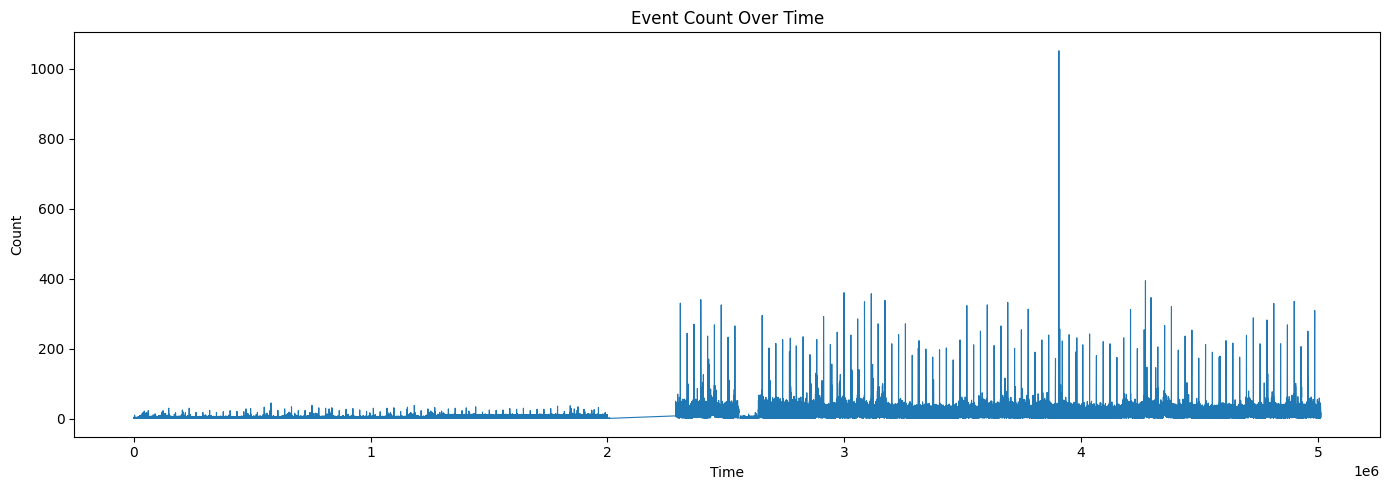

In [2]:
import polars as pl
import seaborn as sns
import os

import matplotlib.pyplot as plt

# Load the dataset
data_path = "./data/cyber1"
files = [f for f in os.listdir(data_path) if f.endswith(".txt")]
print("Files in dataset:", files)

# Load the first file (assuming CSV format)
df = pl.read_csv(os.path.join(data_path, files[0]), has_header=False, batch_size=10_000_000)
print("\nShape:", df.shape)
print("\nSchema:", df.schema)
print("\nFirst 5 rows:")
print(df.head())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for null values
print("\nNull values per column:")
print(df.null_count())

# Plot distributions for numerical columns
num_cols = [col for col, dtype in df.schema.items() if dtype in [pl.Int32, pl.Int64, pl.Float32, pl.Float64]]

if num_cols:
    fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4 * len(num_cols)))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        ax.hist(df[col].drop_nulls().to_list(), bins=50, edgecolor='black')
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot value counts for categorical columns
cat_cols = [col for col, dtype in df.schema.items() if dtype == pl.Utf8]

for col in cat_cols[:5]:  # limit to first 5 categorical columns
    top_vals = df[col].value_counts().sort("count", descending=True).head(20)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=top_vals[col].to_list(), y=top_vals["count"].to_list())
    plt.title(f"Top 20 value counts for {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Time-based analysis if a time column exists
time_col = df.columns[0]  # LANL cyber1 first column is typically time
time_series = df.group_by(time_col).count().sort(time_col)
plt.figure(figsize=(14, 5))
plt.plot(time_series[time_col].to_list(), time_series["count"].to_list(), linewidth=0.8)
plt.title("Event Count Over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# EDA for large auth.txt using Polars lazy API
auth_path = os.path.join(data_path, "auth.txt")
if not os.path.exists(auth_path):
    raise FileNotFoundError(f"File not found: {auth_path}")

# Detect column count from a small sample
sample = pl.read_csv(auth_path, has_header=False, n_rows=5)
default_cols = [
    "time", "src_user", "dst_user", "src_pc", "dst_pc",
    "auth_type", "logon_type", "auth_orient", "success"
]
col_names = default_cols if sample.width == len(default_cols) else [f"col_{i}" for i in range(sample.width)]

# Lazy scan for large-file processing
auth_lf = pl.scan_csv(
    auth_path,
    has_header=False,
    new_columns=col_names,
    infer_schema_length=10_000,
    ignore_errors=True
)

# Basic shape and null counts
row_count = auth_lf.select(pl.len().alias("rows")).collect(streaming=True)
null_counts = auth_lf.select([pl.col(c).null_count().alias(c) for c in col_names]).collect(streaming=True)

print("Rows:")
print(row_count)
print("\nColumns:")
print(col_names)
print("\nNull counts:")
print(null_counts)

# Quick sample
print("\nSample rows:")
print(auth_lf.head(5).collect(streaming=True))

# Top values for categorical columns (first 5 non-time columns)
cat_cols = [c for c in col_names if c != "time"][:5]
for c in cat_cols:
    top_vals = (
        auth_lf.group_by(c)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(20)
        .collect(streaming=True)
    )
    print(f"\nTop 20 values for {c}:")
    print(top_vals)

    plt.figure(figsize=(12, 4))
    sns.barplot(x=top_vals[c].cast(pl.Utf8).to_list(), y=top_vals["count"].to_list())
    plt.title(f"Top 20 value counts for {c}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Time trend (bucketed) if time column exists and is numeric/castable
if "time" in col_names:
    time_trend = (
        auth_lf.with_columns(pl.col("time").cast(pl.Int64, strict=False).alias("time"))
        .drop_nulls(["time"])
        .with_columns((pl.col("time") // 10_000 * 10_000).alias("time_bin"))
        .group_by("time_bin")
        .agg(pl.len().alias("count"))
        .sort("time_bin")
        .collect(streaming=True)
    )

    print("\nTime-bucketed event counts (sample):")
    print(time_trend.head(10))

    plt.figure(figsize=(14, 5))
    plt.plot(time_trend["time_bin"].to_list(), time_trend["count"].to_list(), linewidth=0.8)
    plt.title("Auth Events Over Time (bucket = 10,000 seconds)")
    plt.xlabel("Time bucket")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Success/failure distribution if available
if "success" in col_names:
    success_dist = (
        auth_lf.group_by("success")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect(streaming=True)
    )
    print("\nSuccess distribution:")
    print(success_dist)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=success_dist["success"].cast(pl.Utf8).to_list(), y=success_dist["count"].to_list())
    plt.title("Success vs Failure")
    plt.xlabel("success")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


EDA: auth.txt


: 